# InsurPrime: Can You Guess the Insurance Premium?
by Crédit Agricole Assurances

## Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data loading

In [2]:
X_train = pd.read_csv('Data/x-train')
X_test = pd.read_csv('Data/x-test')
y_train = pd.read_csv('Data/y-train')

/tmp/ipykernel_1995181/1340920901.py:1: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv('Data/x-train')
/tmp/ipykernel_1995181/1340920901.py:2: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv('Data/x-test')


In [3]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (383610, 374)
y_train shape: (383610, 5)
X_test shape: (95852, 374)


In [4]:
X_train.head()

,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,...,NBJRR100_MMAX_A,NBJRR100_MSOM_A,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,1,ACT1,VOC6,1,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
1,2,ACT1,VOC6,1,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
2,3,ACT1,VOC6,1,2,N,R,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,0.402740,NaN,ANNEE5,3
3,4,ACT1,VOC6,2,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,0.246575,NaN,ANNEE5,3
4,5,ACT1,VOC6,2,1,N,N,NaN,NaN,N,...,01. <= 0,01. <= 0,03. <= 102,03. <= 232,04. >= 25,02. <= 57,0.838356,NaN,ANNEE5,3


In [5]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 374 entries, ID to ZONE
dtypes: float64(36), int64(58), object(280)
memory usage: 1.1+ GB


In [6]:
X_train.describe()

,ID,TYPERS,ANCIENNETE,CARACT2,DUREE_REQANEUF,CARACT5,TYPBAT2,DEROG15,CA1,CA2,...,RISK5,RISK7,EQUIPEMENT1,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT6,EQUIPEMENT7,ZONE_VENT,ANNEE_ASSURANCE,ZONE
count,383610.000000,383610.000000,383610.000000,15326.000000,357037.000000,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000,...,357037.000000,357037.000000,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000,365028.00000,383610.000000,383610.000000
mean,191805.500000,1.665368,5.175517,1.019053,2.200483,0.076515,1.061711,99.997263,1047.396444,4.105732,...,448.326103,92.964861,0.074740,0.029454,0.899468,5.905349,6.851302,1.92568,0.701557,49.046876
std,110738.812719,0.471862,3.823097,0.136714,1.300343,0.420928,0.831133,0.286544,4777.346410,329.381340,...,494.892793,8.902888,0.262972,0.566816,0.300708,4.290611,4.329113,0.62817,0.352375,27.919867
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,...,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.002732,1.000000
25%,95903.250000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000,100.000000,0.000000,0.000000,...,4.000000,90.000000,0.000000,0.000000,1.000000,3.000000,4.000000,2.00000,0.389041,25.000000
50%,191805.500000,2.000000,5.000000,1.000000,2.000000,0.000000,1.000000,100.000000,0.000000,0.000000,...,5.000000,100.000000,0.000000,0.000000,1.000000,5.000000,6.000000,2.00000,0.882192,49.000000
75%,287707.750000,2.000000,9.000000,1.000000,2.000000,0.000000,2.000000,100.000000,0.000000,0.000000,...,1000.000000,100.000000,0.000000,0.000000,1.000000,8.000000,9.000000,2.00000,1.000000,73.000000
max,383610.000000,2.000000,11.000000,2.000000,10.000000,20.000000,2.000000,100.000000,30000.000000,30000.000000,...,1000.000000,500.000000,1.000000,87.000000,1.000000,21.000000,21.000000,3.00000,2.000000,95.000000


In [7]:
X_train.columns

Index(['ID', 'ACTIVIT2', 'VOCATION', 'TYPERS', 'ANCIENNETE', 'ADOSS',
       'CARACT1', 'CARACT2', 'CARACT3', 'INDEM1',
       ...
       'NBJRR100_MMAX_A', 'NBJRR100_MSOM_A', 'RR_VOR_MM_A', 'RR_VOR_MMAX_A',
       'RRAB_VOR_MM_A', 'RRAB_VOR_MMAX_A', 'ANNEE_ASSURANCE', 'ESPINSEE',
       'AN_EXERC', 'ZONE'],
      dtype='object', length=374)

The training dataset has 383,610 rows and 374 features, out of which:
- 280 categorical
- 94 numerical

We note that some numerical data appear as strings (e.g., "01. <= 0" for NBJRR100_MSOM_A)

In [8]:
y_train.head()

,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,1,0.0,0.0,1.000000,0.0
1,2,0.0,0.0,1.000000,0.0
2,3,0.0,0.0,0.402740,0.0
3,4,0.0,0.0,0.246575,0.0
4,5,0.0,0.0,0.838356,0.0


In [9]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               383610 non-null  int64  
 1   FREQ             383610 non-null  float64
 2   CM               383610 non-null  float64
 3   ANNEE_ASSURANCE  383610 non-null  float64
 4   CHARGE           383610 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 14.6 MB


In [10]:
y_train.describe()

,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
count,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000
mean,191805.500000,0.012452,182.521632,0.701557,186.087058
std,110738.812719,0.357127,6699.967429,0.352375,6800.490328
min,1.000000,0.000000,-5751.000000,0.002732,-5751.000000
25%,95903.250000,0.000000,0.000000,0.389041,0.000000
50%,191805.500000,0.000000,0.000000,0.882192,0.000000
75%,287707.750000,0.000000,0.000000,1.000000,0.000000
max,383610.000000,182.499998,500000.000000,2.000000,552000.000000


We observe that:
- FREQ: mean 0.01245, median 0, max 182.50
- CM: mean 182.52, median 0, max 500,000, min -5,751
- CHARGE: mean 186.09, median 0, max 552,000, min -5,751
- ANNEE_ASSURANCE: mean 0.7016, range 0.0027

We note that the 25%, 50% and 75% quantiles of FREQ, CM, CHARGE are all 0 => at least 75% of rows have zero values (e.g., no claim observed, rare events).
We also observe that the minimum of CM and CHARGE are both negative, which is rather weird because the claim amounts are usually non negative.

### Missing values

In [11]:
## missing values
X_train.isna().sum().sort_values(ascending=False)

DEROG14            383602
DEROG13            382317
DEROG16            380358
CARACT3            368284
CARACT2            368284
                    ...  
DEROG15                 0
ANNEE_ASSURANCE         0
ID                      0
AN_EXERC                0
ZONE                    0
Length: 374, dtype: int64

We observe a lot of missing data, in particular some columns have a big majority of missing data points. For example DEROG14 has 383602 missing values out of 383,610 (only 8 filled).

In [12]:
# looking at NA counts and rates
n = len(X_train)
na_count = X_train.isna().sum()
na_rate = na_count / n

missing = (
    pd.DataFrame({"na_count": na_count, "na_rate": na_rate})
      .sort_values(["na_rate", "na_count"], ascending=False)
)

display(missing.head(10))

,na_count,na_rate
DEROG14,383602,0.999979
DEROG13,382317,0.996629
DEROG16,380358,0.991523
CARACT2,368284,0.960048
CARACT3,368284,0.960048
TYPBAT1,353336,0.921081
DEROG12,349078,0.909981
BDTOPO_BAT_MAX_HAUTEUR_MAX,237385,0.618819
HAUTEUR,237385,0.618819
HAUTEUR_MAX,237385,0.618819


In [13]:
# we put them into buckets

buckets = pd.Series({
    ">99.5%": int((na_rate > 0.995).sum()),
    ">99%":   int((na_rate > 0.99).sum()),
    ">95%":   int((na_rate > 0.95).sum()),
    ">90%":   int((na_rate > 0.90).sum()),
    ">50%":   int((na_rate > 0.50).sum()),
    "0%":     int((na_rate == 0).sum()),
}).sort_index()

print("\nMissingness buckets (#columns):")
display(buckets)


Missingness buckets (#columns):


0%         96
>50%      183
>90%        7
>95%        5
>99%        3
>99.5%      2
dtype: int64

The dataset is highly sparse in a structured way, most columns have a lot of missing data. This is probably the case because these columns describe a specific type of building or optional clauses which are not applicable for the whole dataset. The missing values are likely useful and informative in this case (and should not be treated as noise). However, a good way to about it would be to drop the 5 columns with more than 99% missing values (as they have no predictive power).

### Target profiling

In [14]:
targets = ["FREQ", "CM", "CHARGE", "ANNEE_ASSURANCE"]
# zero / positive / negative
profile = []
for c in targets:
    s = y_train[c]
    profile.append({
        "target": c,
        "pct_zero": (s == 0).mean() * 100,
        "pct_negative": (s < 0).mean() * 100,
        "pct_positive": (s > 0).mean() * 100,
        "n_unique": s.nunique(dropna=True),
    })
profile = pd.DataFrame(profile).set_index("target")
print("\nTarget profile:")
display(profile)

# Tail quantiles CHARGE
qs = [0.90, 0.95, 0.99, 0.995, 0.999]
print("\nCHARGE tail quantiles:")
display(y_train["CHARGE"].quantile(qs))


Target profile:


,pct_zero,pct_negative,pct_positive,n_unique
target,,,,
FREQ,99.245588,0.000000,0.754412,470
CM,99.385313,0.001564,0.613123,1826
CHARGE,99.385313,0.001564,0.613123,1825
ANNEE_ASSURANCE,0.000000,0.000000,100.000000,1113



CHARGE tail quantiles:


0.900        0.00000
0.950        0.00000
0.990        0.00000
0.995      400.00000
0.999    31317.70582
Name: CHARGE, dtype: float64

We observe the following:

- $\bold{FREQ}$ : 99.25% zeros making it an extremely rare event => Only 0.75% policies have a claim => strong class imbalance

- $\bold{CM}$ : 99.38% zeros, only 0.61% positive. Almost entirely driven by claim occurrence. Negatives are very rare probably standing for recoveries.
Severity should likely be modeled conditional on FREQ > 0.

- $\bold{CHARGE}$ : Same structure as CM. Negatives are negligible.
RMSE might be dominated by very few large losses.
Up to 99% of the dat points are all zeros and only top 0.5% start becoming positive => extremely heavy tail. This is a highly skewed loss distribution.

- $\bold{ANNEE ASSURANCE}$ : No zeros, continuous between 0 and 2 (exposure time). Should be used as an offset in frequency model. Not something to predict, purely scaling.

In [15]:
## we check the formula: CHARGE = FREQ * CM * ANNEE_ASSURANCE

pred_charge = y_train["FREQ"] * y_train["CM"] * y_train["ANNEE_ASSURANCE"]
diff = y_train["CHARGE"] - pred_charge

formula_check = pd.Series({
    "mean_abs_error": diff.abs().mean(),
    "median_abs_error": diff.abs().median(),
    "max_abs_error": diff.abs().max(),
    "pct_exact": (diff == 0).mean() * 100,
    "pct_within_1e-6": (diff.abs() <= 1e-6).mean() * 100,
    "pct_within_1e-3": (diff.abs() <= 1e-3).mean() * 100,
})
print("\nCHARGE formula check:")
display(formula_check)


CHARGE formula check:


mean_abs_error      6.408036e-15
median_abs_error    0.000000e+00
max_abs_error       1.164153e-10
pct_exact           9.989077e+01
pct_within_1e-6     1.000000e+02
pct_within_1e-3     1.000000e+02
dtype: float64

Errors are essentially zero, confirming that:

CHARGE = FREQ × CM × ANNEE_ASSURANCE

So modeling FREQ and CM separately is perfectly valid.

In [16]:
# Annee assurance in X and y
corr = np.corrcoef(X_train["ANNEE_ASSURANCE"], y_train["ANNEE_ASSURANCE"])[0, 1]
print("\nCorr(ANNEE_ASSURANCE in X_train, y_train):", corr)

print("\nANNEE_ASSURANCE distribution:")
display(X_train["ANNEE_ASSURANCE"].describe())


Corr(ANNEE_ASSURANCE in X_train, y_train): 0.9999999999999999

ANNEE_ASSURANCE distribution:


count    383610.000000
mean          0.701557
std           0.352375
min           0.002732
25%           0.389041
50%           0.882192
75%           1.000000
max           2.000000
Name: ANNEE_ASSURANCE, dtype: float64

The correlation is very close to 1 and so it is identical in X and y, meaning that there is no leakage or mismatch. ANNEE_ASSURANCE should be an offset in frequency models and a multiplicative factor at the end.

### Categorical / Numeric columns

In [17]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Object cardinality
cat_card = X_train[cat_cols].nunique(dropna=True).sort_values(ascending=False)
print("\nTop 10 categorical cardinalities:")
display(cat_card.head(10).to_frame("n_unique"))

print("\nLowest 10 categorical cardinalities:")
display(cat_card.tail(10).sort_values().to_frame("n_unique"))


Top 10 categorical cardinalities:


,n_unique
SURFACE4,16
SURFACE6,16
INDEM2,12
TAILLE1,10
MEN_COLL,10
TAILLE2,10
PROPORTION_21,10
PROPORTION_22,10
PROPORTION_23,10
PROPORTION_24,10



Lowest 10 categorical cardinalities:


,n_unique
IND_Y1_Y2,1
IND_INC,1
DEROG14,1
DISTANCE_244,1
KAPITAL40,2
ADOSS,2
DEROG11,2
KAPITAL34,2
KAPITAL38,2
KAPITAL39,2


All objects have a relatively low-cardinality (max 16) so they're quite manageable. Some variables (4) have only 1 unique value and so they don't provide any information (it's better to drop them as they don't provide any information). Some variables are binary with 2 unique values.

In [18]:
# Numeric unique counts (to detect coded categoricals)
num_unique = X_train[num_cols].nunique(dropna=True).sort_values()
print("\nLowest 10 numeric unique counts (often coded/categorical):")
display(num_unique.head(10).to_frame("n_unique"))

print("\nHighest 30 numeric unique counts (usually continuous):")
display(num_unique.tail(30).to_frame("n_unique"))


Lowest 10 numeric unique counts (often coded/categorical):


,n_unique
TYPERS,2
CARACT2,2
DEROG15,2
KAPITAL5,2
KAPITAL2,2
KAPITAL3,2
KAPITAL4,2
KAPITAL1,2
KAPITAL9,2
KAPITAL8,2



Highest 30 numeric unique counts (usually continuous):


,n_unique
KAPITAL10,13
KAPITAL11,13
SURFACE13,13
NBBAT9,16
CARACT5,16
NBBAT2,16
TAILLE3,17
SURFACE7,19
SURFACE10,19
KAPITAL25,21


We observe that many numerical variables are actually categorical classes, particularly:
- Variables with 2 unique counts likely encode binary caategorical classes (0/1) and not continuous ones. 
- As for variables with multiple unique counts: ID represents an identifier and should not be considered as continuous (nor used for prediction). Zone probably refers to a geographic code (so not continuous) it might be a good idea to treat it as categorical.

In [19]:
# Magic values check
magic_vals = [999, 1000, 9999, 99999, -1]
magic_rows = []
for c in num_cols:
    s = X_train[c]
    counts = {f"count_{v}": int((s == v).sum()) for v in magic_vals}
    if any(v > 0 for v in counts.values()):
        counts["col"] = c
        magic_rows.append(counts)

magic_df = pd.DataFrame(magic_rows).set_index("col") if magic_rows else pd.DataFrame()
print("\nNumeric columns with magic values (999/1000/9999/99999/-1):")
display(magic_df.sort_values(list(magic_df.columns), ascending=False) if not magic_df.empty else magic_df)


Numeric columns with magic values (999/1000/9999/99999/-1):


,count_999,count_1000,count_9999,count_99999,count_-1
col,,,,,
ID,1,1,1,1,0
KAPITAL25,0,219457,0,0,0
RISK3,0,159204,0,0,37
RISK1,0,159204,0,0,2
RISK2,0,159204,0,0,0
RISK4,0,159204,0,0,0
RISK5,0,159204,0,0,0
KAPITAL24,0,18850,0,0,0
KAPITAL23,0,16757,0,0,0


- Value 1000: Appears massively in RISK*, KAPITAL*, SURFACE*. Probabbly certainly a sentinel code (not real numeric value) = >Likely means “not applicable” / default band => Recode as NaN or separate category.

- Value -1 (rare): Likely error/missing code => Safe to convert to NaN.

### Relevant plots

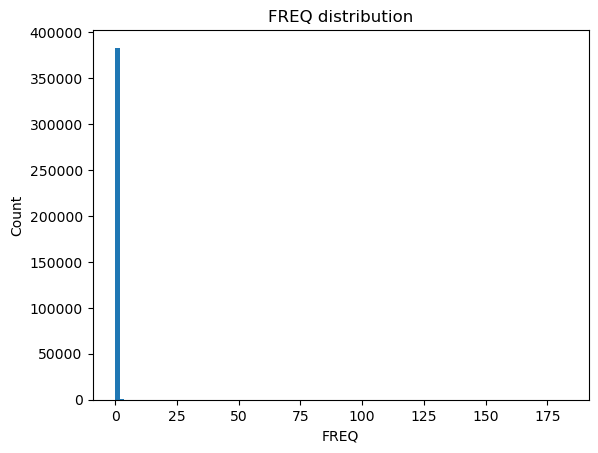

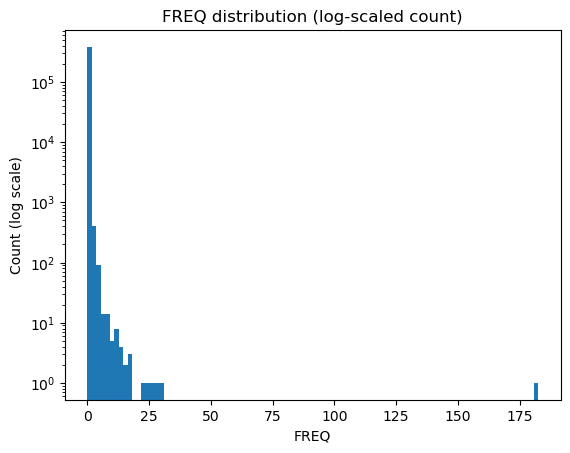

In [20]:
# freq dist
plt.figure()
y_train["FREQ"].plot(kind="hist", bins=100)
plt.title("FREQ distribution")
plt.xlabel("FREQ")
plt.ylabel("Count")
plt.show()

# log scale
plt.figure()
y_train["FREQ"].plot(kind="hist", bins=100)
plt.yscale("log")
plt.title("FREQ distribution (log-scaled count)")
plt.xlabel("FREQ")
plt.ylabel("Count (log scale)")
plt.show()

There is a massive spike at 0, cnfirming that it is an extremely rare event. Very few observations have positive counts, and we have a long tail.

ANNEE_ASSURANCE could be used as an offset in frequency modeling.

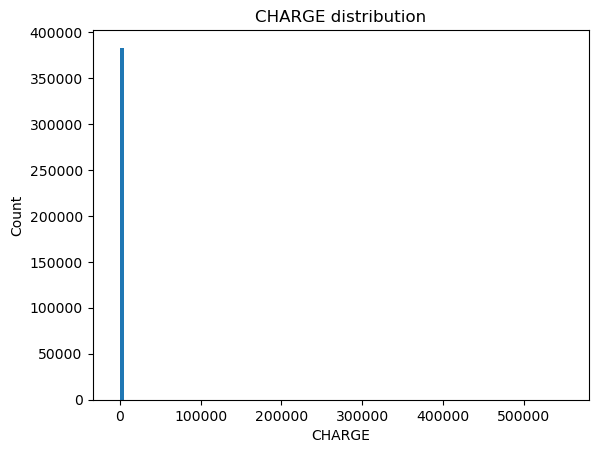

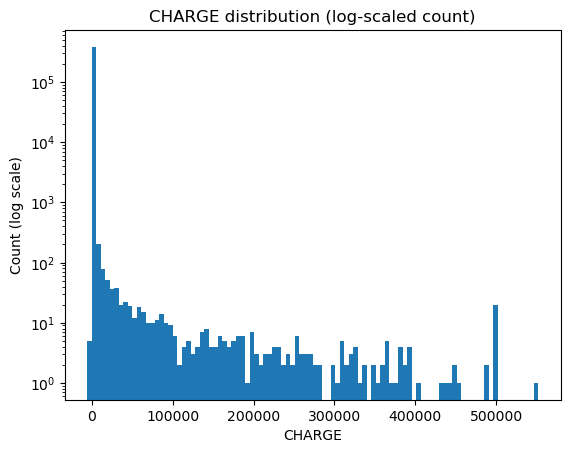

In [21]:
# charge dist
plt.figure()
y_train["CHARGE"].plot(kind="hist", bins=100)
plt.title("CHARGE distribution")
plt.xlabel("CHARGE")
plt.ylabel("Count")
plt.show()

# log scale
plt.figure()
y_train["CHARGE"].plot(kind="hist", bins=100)
plt.yscale("log")
plt.title("CHARGE distribution (log-scaled count)")
plt.xlabel("CHARGE")
plt.ylabel("Count (log scale)")
plt.show()

The huge spike at 0 confirms extreme zero inflation. The rest of the distribution is compressed on the left due to a very long right tail.

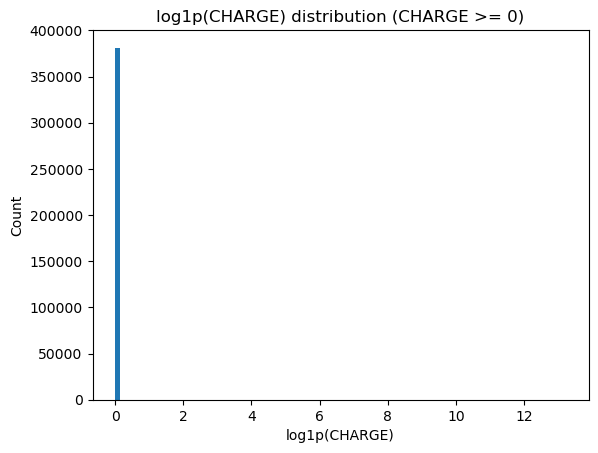

In [22]:
# Log view for CHARGE >= 0
nonneg_charge = y_train.loc[y_train["CHARGE"] >= 0, "CHARGE"]
plt.figure()
np.log1p(nonneg_charge).plot(kind="hist", bins=100)
plt.title("log1p(CHARGE) distribution (CHARGE >= 0)")
plt.xlabel("log1p(CHARGE)")
plt.ylabel("Count")
plt.show()

The log1p(charge) still shows a big spike at zero, however the tail is much smaller with large losses more compressed.

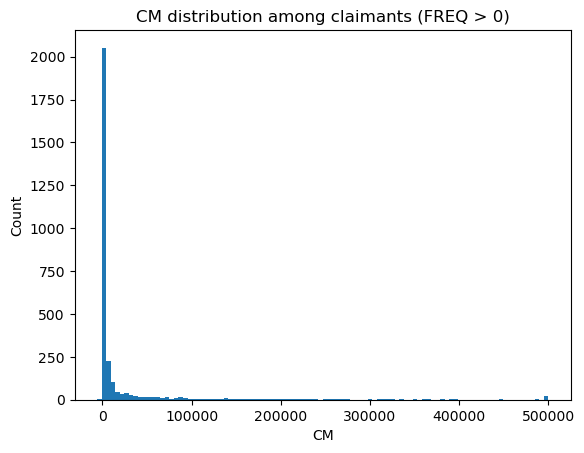

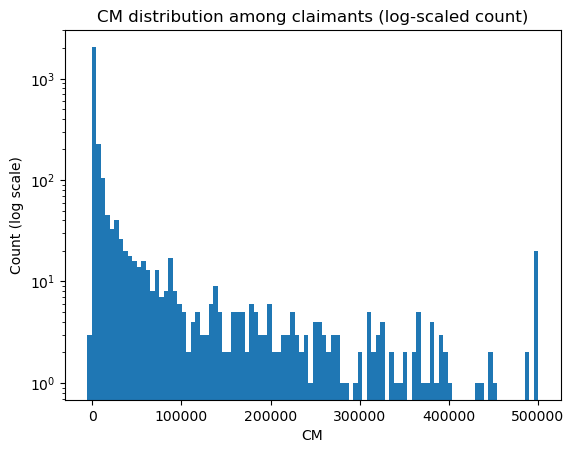

In [23]:
# severity among claimants
claimants = y_train["FREQ"] > 0
plt.figure()
y_train.loc[claimants, "CM"].plot(kind="hist", bins=100)
plt.title("CM distribution among claimants (FREQ > 0)")
plt.xlabel("CM")
plt.ylabel("Count")
plt.show()

# log scale
plt.figure()
y_train.loc[claimants, "CM"].plot(kind="hist", bins=100)
plt.yscale("log")
plt.title("CM distribution among claimants (log-scaled count)")
plt.xlabel("CM")
plt.ylabel("Count (log scale)")
plt.show()

CM distribution among claimants shows a strong right skew so we have many small claims, few very large ones. Variance is very high relative to the mean.

### Taking a closer look at Risk

In [24]:
# we take a closer look at Risk to figure out whether they are actual numeric columns or they stand for categorical features
risk_cols = [c for c in X_train.columns if c.startswith("RISK")]

X_train[risk_cols]


,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,O,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,O,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,R,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,O,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
383605,2.0,28.0,10.0,3.0,4.0,O,90.0,N,N,NaN,N,N,N
383606,2.0,31.0,11.0,3.0,5.0,O,95.0,O,N,N,O,N,N
383607,5.0,34.0,9.0,7.0,4.0,O,100.0,O,N,N,O,N,O
383608,3.0,36.0,12.0,3.0,5.0,O,100.0,O,N,NaN,N,N,N


In [25]:
X_train[risk_cols].describe()

,RISK1,RISK2,RISK3,RISK4,RISK5,RISK7
count,357037.000000,357037.000000,357037.000000,357037.000000,357037.000000,357037.000000
mean,447.408790,461.452603,451.235866,447.763770,448.326103,92.964861
std,495.715377,483.135360,492.285691,495.397245,494.892793,8.902888
min,-1.000000,3.000000,-3.000000,1.000000,0.000000,75.000000
25%,3.000000,27.000000,9.000000,3.000000,4.000000,90.000000
50%,3.000000,35.000000,13.000000,5.000000,5.000000,100.000000
75%,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,100.000000
max,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,500.000000


The RISK* variables take a small number of discrete integer levels with a dominant sentinel value (1000), rather than a smooth continuous range, indicating they are risk classes or rating bands, not numeric expectations. Therefore, their numeric spacing has no true quantitative meaning, so they should be treated as categorical variables.

### Correlation Analysis

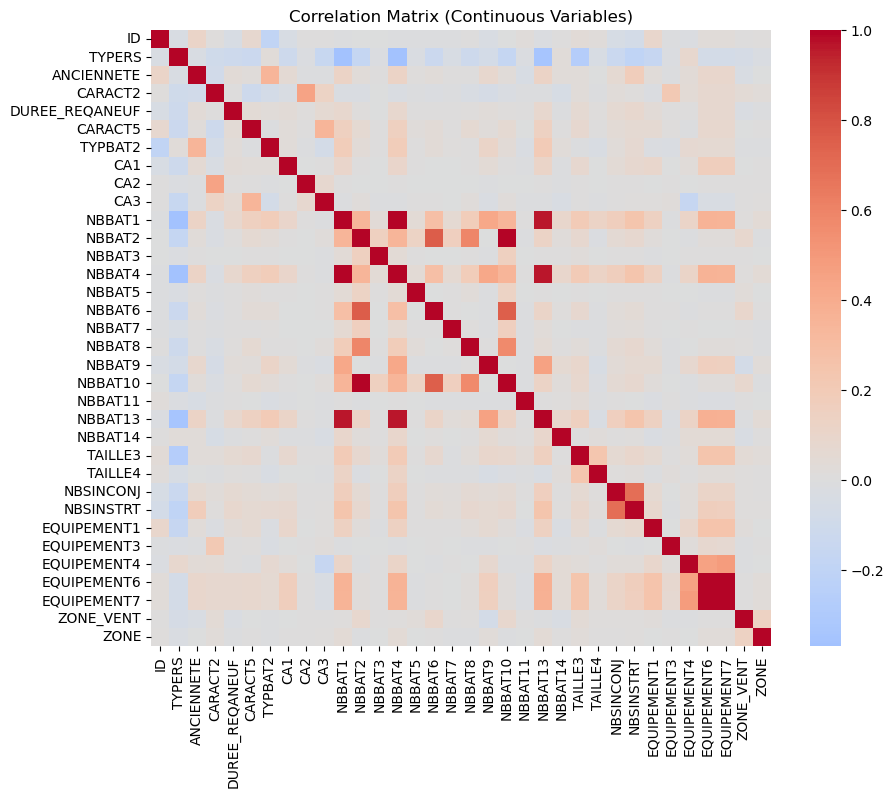

In [26]:
# numeric columns
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Remove coded families + offset
exclude_prefixes = ("SURFACE", "KAPITAL", "RISK", "DEROG")
continuous_cols = [
    c for c in num_cols
    if not c.startswith(exclude_prefixes)
    and c != "ANNEE_ASSURANCE"
]

corr = X_train[continuous_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Continuous Variables)")
plt.show()

In [27]:
# Extract high correlations
threshold = 0.8

high_corr = (
    corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

high_corr.columns = ["Var1", "Var2", "Correlation"]
high_corr = high_corr[high_corr["Correlation"] > threshold]

print("Highly correlated pairs (>|0.8|):")
display(high_corr.sort_values("Correlation", ascending=False))

Highly correlated pairs (>|0.8|):


,Var1,Var2,Correlation
287,NBBAT1,NBBAT4,0.999806
555,EQUIPEMENT6,EQUIPEMENT7,0.998664
315,NBBAT2,NBBAT10,0.997337
295,NBBAT1,NBBAT13,0.958765
358,NBBAT4,NBBAT13,0.958691


In [28]:
X_cont = X_train[continuous_cols].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_cont.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_cont.values, i)
    for i in range(X_cont.shape[1])
]

display(vif_data.sort_values("VIF", ascending=False))


,Variable,VIF
13,NBBAT4,8586.356775
10,NBBAT1,8059.257721
31,EQUIPEMENT7,1766.691306
30,EQUIPEMENT6,1469.602062
21,NBBAT13,415.865903
11,NBBAT2,401.148321
19,NBBAT10,214.190322
3,CARACT2,62.641639
15,NBBAT6,44.495142
17,NBBAT8,19.821938


We observe the following:
- Severe multicollinearity among NBBAT* variables (corr around 0.99, VIF > 2000) -> they are almost duplicates.
- EQUIPEMENT6 and EQUIPEMENT7 are nearly identical (corr around 0.999, VIF > 1000).

If a GLM model is used, it is preferable to remove redundant NBBAT & EQUIPEMENT duplicates.

## Main observations

- Extreme zero inflation: around 99% of FREQ and CHARGE are zero -> rare events.
- Heavy-tail: Few very large claims dominate variance.
- Missing values: Many variables have more than 50% missing values -> likely “not applicable”.
- Coded numeric variables: Values like 1000 and -1 are sentinel codes, not real magnitudes (continuous).

## Data Cleaning

In [29]:
# Drop ID
X_train = X_train.drop(columns=["ID"])

# Drop single-value columns
single_val_cols = X_train.columns[X_train.nunique(dropna=True) <= 1]
X_train = X_train.drop(columns=single_val_cols)

# Drop ultra-sparse columns
na_rate = X_train.isna().mean()
X_train = X_train.loc[:, na_rate <= 0.995]

# Convert fake codes to NaN
sentinel_cols = [c for c in X_train.columns if c.startswith(("SURFACE", "KAPITAL", "RISK"))]
X_train[sentinel_cols] = X_train[sentinel_cols].replace({1000: np.nan, -1: np.nan})
# X_train = X_train.replace({1000: np.nan, -1: np.nan})

# Convert binary numeric columns to categorical
num_cols = X_train.select_dtypes(include=[np.number]).columns
binary_num_cols = [c for c in num_cols if X_train[c].nunique(dropna=True) == 2]
X_train[binary_num_cols] = X_train[binary_num_cols].astype("category")

# Convert Coded Numerics to Categorical
coded_prefixes = ("SURFACE", "KAPITAL", "RISK")
coded_cols = [c for c in num_cols if c.startswith(coded_prefixes)] + ["ZONE"]
coded_cols = list(dict.fromkeys(coded_cols))
X_train[coded_cols] = X_train[coded_cols].astype("category")

# Missing indicator
#for col in X_train.columns:
#    if X_train[col].isna().any():
#        X_train[col + "_missing"] = X_train[col].isna().astype(int)


In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 368 entries, ACTIVIT2 to ZONE
dtypes: category(64), float64(5), int64(24), object(275)
memory usage: 913.2+ MB
